# CAPSTONE: Pardavimų ir klientų elgsenos analizė (Supermarket Sales)

**Duomenų rinkinys:** Supermarket Sales 
https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales


**Formatas:** Jupyter Notebook (`.ipynb`) ir analizė (1-3 puslapiai analitika ir 1 puslapis executive versija)

Tikslas – atlikti pilną analizės ciklą: duomenų supratimas, EDA, pasikliautiniai intervalai, hipotezių testavimas ir dvi analitinės dalys: regresija ir laiko eilučių analizė.

Pastaba: šiame faile pateikiamos užduotys (TO DO) ir užkomentuoti pavyzdiniai fragmentai. Reikia pasirinkti analitinę kryptį, analizuojamus kintamuosius, atlikti analizę ir pateikti išvadas.


##  Aplinkos paruošimas

- Importuoti pagrindines bibliotekas.
- Užtikrinti, kad grafikai būtų aiškūs (pavadinimai, ašys).


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Duomenų įkėlimas

- Įkelti CSV failą.
- Patikrinti, ar `df` egzistuoja ir ar matosi pirmos eilutės.


In [3]:
df = pd.read_csv("SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Duomenų supratimas ir paruošimas

- Patikrinti duomenų dydį (`shape`) ir stulpelių pavadinimus.
- Patikrinti duomenų tipus (`info`).
- Patikrinti trūkstamas reikšmes (missing values).
- Jei yra datos stulpelis (pvz., `Date`), konvertuoti į datetime.
- Jei reikia, sutvarkyti netinkamus duomenų tipus (pvz., `Total` į float).


In [4]:
df.shape
df.columns.tolist()


['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [6]:
df.isna().sum().sort_values(ascending=False)

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 3. Aprašomoji analizė (EDA)

- Pasirinkti 1–2 skaitinius kintamuosius ir pateikti jų pagrindines statistikas (mean, median, std, min, max).
- Pateikti 3-5 grafikus:
  1) Pasiskirstymas (pvz., `Total`)
  2) Palyginimas tarp grupių (pvz., `Total` pagal `Branch` arba `Product line`)
  3) Kategorinio kintamojo pasiskirstymas (pvz., `Payment` arba `Customer type`)
- Po kiekvieno grafiko trumpai aprašyti, ką jis rodo.


In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unit price,1000.0,55.67213,10.08,32.875,55.23,77.935,99.96,26.494628
Quantity,1000.0,5.51,1.0,3.0,5.0,8.0,10.0,2.923431
Tax 5%,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Sales,1000.0,322.966749,10.6785,124.422375,253.848,471.35025,1042.65,245.885335
Date,1000,2019-02-14 00:05:45.600000,2019-01-01 00:00:00,2019-01-24 00:00:00,2019-02-13 00:00:00,2019-03-08 00:00:00,2019-03-30 00:00:00,NaN
cogs,1000.0,307.58738,10.17,118.4975,241.76,448.905,993.0,234.17651
gross margin percentage,1000.0,4.761905,4.761905,4.761905,4.761905,4.761905,4.761905,0.0
gross income,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Rating,1000.0,6.9727,4.0,5.5,7.0,8.5,10.0,1.71858


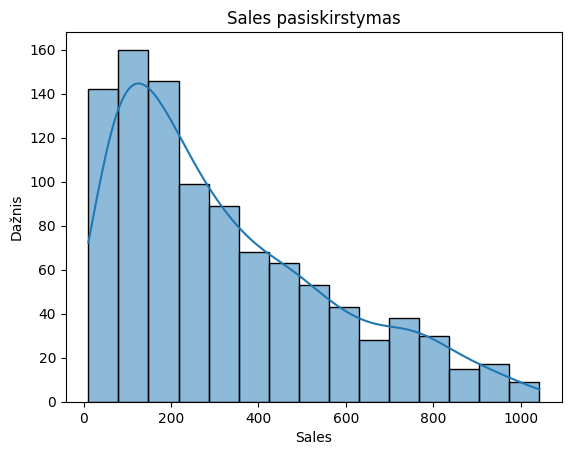

In [9]:
sns.histplot(df["Sales"], kde=True)

plt.title("Sales pasiskirstymas")
plt.xlabel("Sales")
plt.ylabel("Dažnis")

plt.show()

The distribution of sales is right-skewed, meaning that most transactions are relatively small, while a smaller number of purchases have much higher values. Most sales fall roughly between 100 and 400.

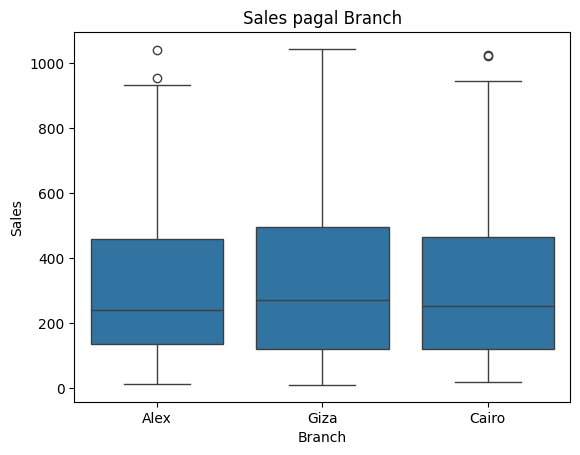

In [10]:
sns.boxplot(data=df, x="Branch", y="Sales")

plt.title("Sales pagal Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")

plt.show()

The boxplot shows that the distribution of sales is fairly similar across all three branches (Alex, Giza, Cairo). Although there are some differences in medians and spread, there is no clear branch that consistently generates significantly higher transaction values.

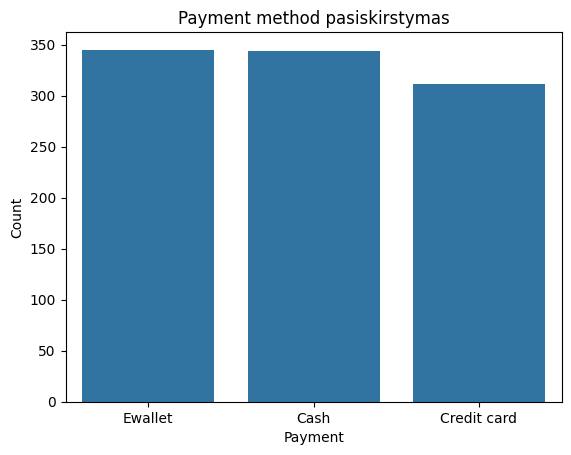

In [11]:
sns.countplot(data=df, x="Payment")

plt.title("Payment method pasiskirstymas")
plt.xlabel("Payment")
plt.ylabel("Count")

plt.show()

The count plot indicates that Ewallet and Cash are the most frequently used payment methods, while Credit card payments are slightly less common.

## 4. 95 % pasikliautinis intervalas (CI)

- Pasirinkti vieną skaitinį kintamąjį (pvz., `Total`, `gross income`, `Rating`).
- Apskaičiuoti 95 % pasikliautinį intervalą vidurkiui.
- Parašyti interpretaciją: ką intervalas reiškia praktiniame kontekste.

Pastaba:
- Galima naudoti t-skirstinį (`stats.t.ppf`) ir standartinę paklaidą (SE).


In [12]:
col = "Sales"

x = df[col].dropna().astype(float).values
n = len(x)
mean = x.mean()
std = x.std(ddof=1)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
se = std / np.sqrt(n)

ci_low = mean - t_crit * se
ci_high = mean + t_crit * se

print("Mean:", mean)
print("95% CI:", (ci_low, ci_high))
print("Sample size:", n)

Mean: 322.966749
95% CI: (np.float64(307.7084118264187), np.float64(338.2250861735813))
Sample size: 1000


The average sales value in the dataset is approximately 322.97.
With 95% confidence, the true average sales value for the population lies between 307.71 and 338.23.

## 5. Hipotezių testavimas (H0 ir Ha)

- Pasirinkti ir atlikti bent vieną testą (rekomenduojama pasirinkti 1 testą, atlikti teisingai ir aiškiai paaiškinti):
  - t-test (2 grupės, skaitinis target)
  - ANOVA (3+ grupės, skaitinis target)
  - Chi-square (2 kategoriniai)
- Parašyti H0 ir Ha.
- Pateikti p reikšmę.
- Padaryti išvadą paprastais žodžiais.
- Papildomai pateikti praktinį efektą (pvz., vidurkių skirtumą).

Žemiau palikti užkomentuoti šablonai.


In [13]:
target = "Sales"
group = "Customer type"

g1 = df.loc[df[group] == "Member", target].dropna().astype(float)
g2 = df.loc[df[group] == "Normal", target].dropna().astype(float)

t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)

print("t statistic:", t_stat)
print("p-value:", p_val)

t statistic: 1.8862430247260686
p-value: 0.059565974044416076


A two-sample t-test was conducted to compare the average sales between Member and Normal customers. The p-value (0.0596) is greater than the significance level of 0.05, therefore the null hypothesis cannot be rejected. This indicates that there is no statistically significant difference in average sales between the two customer types.

## 6. Regresinė analizė (privaloma)

Tikslas: prognozuoti pasirinktą skaitinį target (pvz., `Total`).

- Pasirinkti target ir bent 5–8 features (gali būti skaitiniai ir kategoriniai).
- Paruošti `X` ir `y`.
- Kategorinius paversti į dummy, naudoti `drop_first=True`.
- BŪTINA: po `get_dummies` naudoti `.astype(float)`, kad nekiltų `ValueError` su OLS.
- Padalinti į train/test (pvz., 80/20).
- Apmokyti OLS modelį (statsmodels).
- Įvertinti modelį su R², MAE, RMSE test rinkinyje.
- Trumpai interpretuoti 2–3 svarbiausius koeficientus (ką reiškia verslo prasme).

Žemiau paliktas užkomentuoti kodo pavyzdžiai.


In [15]:
target = "Sales"
features = ["Quantity", "Unit price"]

X = df[features]
y = df[target]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     3097.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:44:02   Log-Likelihood:                -4661.8
No. Observations:                 800   AIC:                             9330.
Df Residuals:                     797   BIC:                             9344.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -322.1599      8.711    -36.982      0.0

In [22]:
X_test_sm = sm.add_constant(X_test)

y_pred = model.predict(X_test_sm)

In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 58.537046580324485
RMSE: 78.9179669700677
R²: 0.9042708171993605


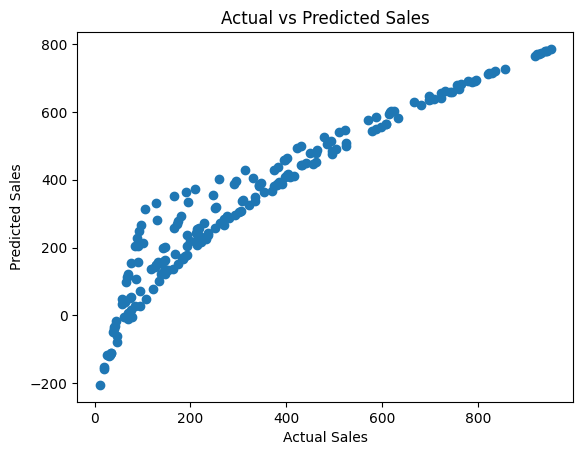

In [24]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

A linear regression model was used to predict sales based on quantity and unit price. The model achieved an R² of approximately 0.90, meaning that about 90% of the variation in sales can be explained by these variables. Both predictors are statistically significant (p < 0.001).
The coefficient for quantity indicates that increasing the quantity purchased leads to a higher sales value, while the unit price also positively influences the total sales amount.

The evaluation metrics (MAE ≈ 58.5 and RMSE ≈ 78.9) indicate that the model predictions are reasonably close to the actual sales values.

## 7. Laiko eilučių analizė (privaloma)

Tikslas: įvertinti pardavimų dinamiką laike, naudojant agreguotus pardavimus pagal dieną arba mėnesį.

- Konvertuoti datą į datetime (jei reikia).
- Sukurti laiko eilutę: agreguoti `Total` (ar kitą pardavimų metriką) pagal datą.
- Pavaizduoti laiko eilutę grafike.
- Aprašyti, ar matoma tendencija / sezoniškumas / šuoliai.
- Pateikti paprastą prognozės pavyzdį:
  - slenkantis vidurkis, arba
  - paskutinių N periodų vidurkis kaip „forecast“.

Sudėtingų modelių nereikalaujama (ARIMA/Prophet nebūtini).


In [25]:
sales_by_day = df.groupby("Date")["Sales"].sum().reset_index()

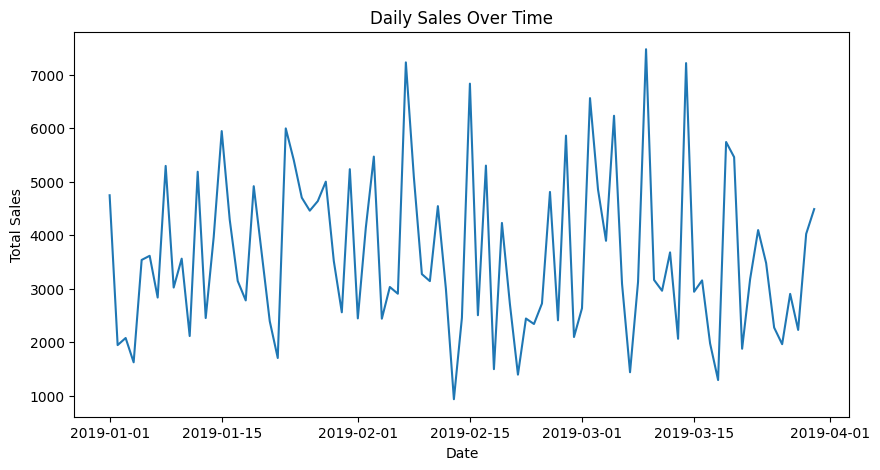

In [26]:
plt.figure(figsize=(10,5))

plt.plot(sales_by_day["Date"], sales_by_day["Sales"])

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [27]:
sales_by_day["MA7"] = sales_by_day["Sales"].rolling(window=7).mean()

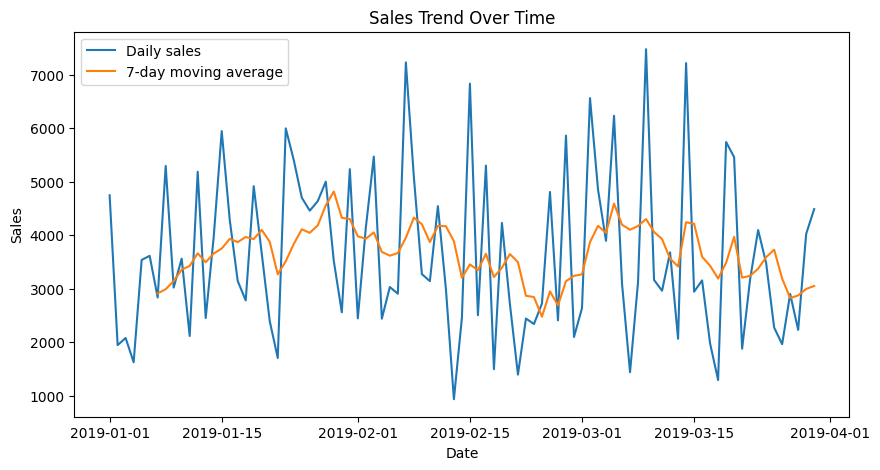

In [28]:
plt.figure(figsize=(10,5))

plt.plot(sales_by_day["Date"], sales_by_day["Sales"], label="Daily sales")
plt.plot(sales_by_day["Date"], sales_by_day["MA7"], label="7-day moving average")

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

The time series analysis shows how total daily sales change over time. While daily sales fluctuate significantly from day to day, the 7-day moving average highlights the general trend in sales. No strong seasonal pattern is clearly visible in the dataset, but short-term variations and peaks in sales activity can be observed.

## 8. Išvados

- Trumpai apibendrinti EDA radinius (2–4 punktai).
- Pateikti CI interpretaciją (1–2 sakiniai).
- Pateikti hipotezių testo išvadą (H0/Ha + p reikšmė + interpretacija).
- Apibendrinti regresijos rezultatus (metrikos + 2–3 koeficientų prasmė).
- Apibendrinti laiko eilučių analizę (tendencijos + paprastos prognozės mintis).
- Pateikti 2–3 rekomendacijas verslui.


The exploratory data analysis showed that most supermarket transactions fall within a moderate sales range, with some higher-value purchases creating a right-skewed distribution. Sales values appear to be relatively similar across different branches.

The confidence interval analysis estimated that the true average sales value lies between 307.71 and 338.23 with 95% confidence.

The hypothesis testing results showed that there is no statistically significant difference in average sales between Member and Normal customers.

The regression analysis demonstrated that quantity and unit price are strong predictors of sales, explaining around 90% of the variation in the sales value.

Time series analysis revealed fluctuations in daily sales but did not show strong seasonal patterns.

Based on the analysis, businesses can focus on strategies that increase the quantity of items purchased per transaction, since quantity has a strong effect on total sales. Promotions such as bundle offers or discounts for multiple items may increase revenue.

Since payment methods are relatively balanced, maintaining multiple convenient payment options is important for customer satisfaction.

## Priedas: dažnos klaidos (kontrolinis sąrašas)

- Po `pd.get_dummies(...)` pritaikyta `.astype(float)`, kad OLS nemestų `ValueError`.
- Test rinkinys nenaudotas modelio pasirinkimui (jei buvo lyginami variantai, sprendimas priimtas pagal train/validation arba aiškiai aprašytas).
- Grafikai privalo turėti pavadinimus ir ašių pavadinimus.
- Po testų turi būti pateikta ne tik p reikšmė, bet ir praktinis efektas (pvz., vidurkių skirtumas).
- Svarbu nepalikti neužkomentuotų kodo nuotrupų, tarpinių skaičiavimų. 

